# Phase 9 — Model Explainability

This notebook generates separate SHAP explanations for the validated financial-inclusion and mobile-money pipelines. Global results use protected holdouts; local contributions are aggregated to original input fields and validated against each model's score.

In [1]:
from pathlib import Path
import os, sys
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MPLBACKEND', 'Agg')
project_root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'pyproject.toml').is_file())
sys.path.insert(0, str(project_root / 'src'))
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from finaccess_eswatini.phase9_explainability import run
summary = run()
report_dir = project_root / 'reports' / 'phase_9'
print('SHAP version:', summary['shap_version'])
for key, result in summary['models'].items():
    print(key, result['explainer_type'], '— holdout rows:', result['holdout_rows_explained'])

C:\Users\Thando F Dlamini\Documents\FinAccess Eswatini\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.52.0
model1 TreeExplainer — holdout rows: 211
model2 LinearExplainer — holdout rows: 210


## Global model behaviour

Mean absolute SHAP values rank how strongly each original input field changes predictions across the relevant protected holdout. Importance is predictive, not causal.

,model,model_label,source_feature,feature_label,mean_abs_shap_log_odds,mean_signed_shap_log_odds,importance_share,rank
0,model1,Financial Inclusion,age_group,age group,0.3348,-0.0138,0.1887,1
1,model1,Financial Inclusion,emp_in,workforce status,0.3202,-0.0106,0.1805,2
2,model1,Financial Inclusion,inc_q,income quintile,0.2666,0.0510,0.1502,3
3,model1,Financial Inclusion,educ,education level,0.2230,-0.0002,0.1257,4
4,model1,Financial Inclusion,internet_use,recent internet use,0.2027,0.0147,0.1142,5
5,model1,Financial Inclusion,con11,SIM registration in own name,0.1278,0.0011,0.0720,6
6,model1,Financial Inclusion,con18,phone PIN or password,0.1128,-0.0018,0.0636,7
7,model1,Financial Inclusion,con20,rules imposed on own-phone use,0.0649,0.0119,0.0366,8
8,model1,Financial Inclusion,fin46,ID ownership,0.0401,0.0076,0.0226,9
9,model1,Financial Inclusion,fin24c,natural-disaster or severe-weather experience,0.0237,0.0058,0.0134,10


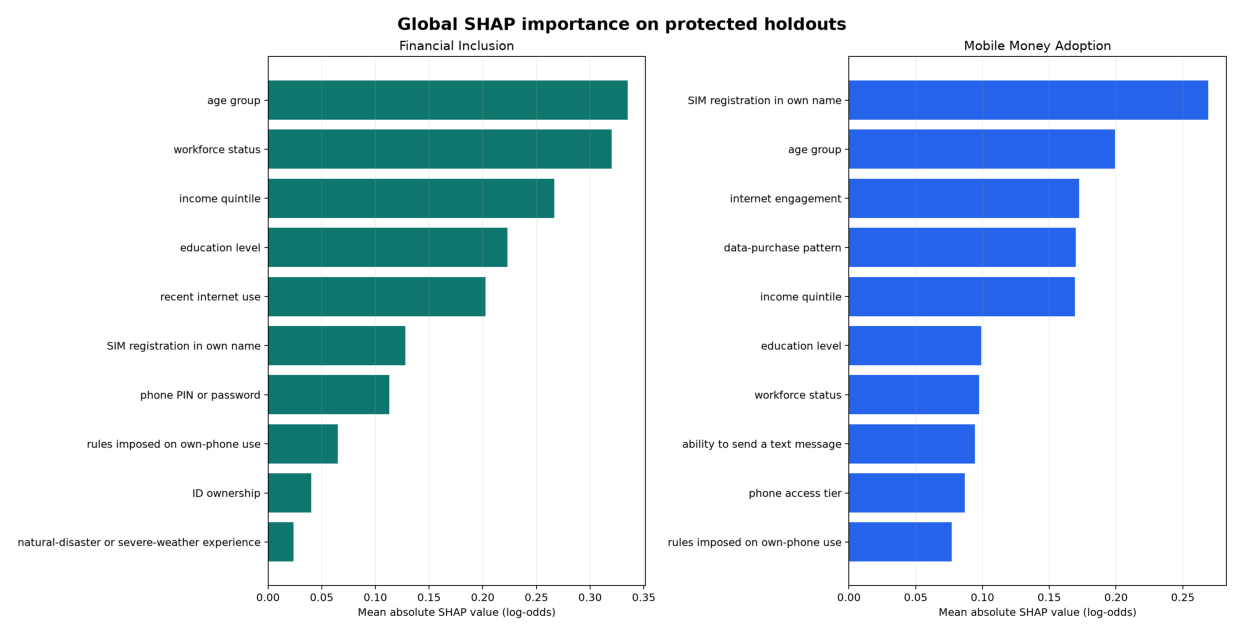

In [2]:
global_shap = pd.read_csv(report_dir / 'global_shap_importance.csv')
display(global_shap.groupby('model', sort=False).head(10).round(4))
image = mpimg.imread(report_dir / 'figures' / '01_global_shap_importance.png')
plt.figure(figsize=(16, 8))
plt.imshow(image)
plt.axis('off')
plt.show()

## Individual, model-derived explanations

Positive values raise the prediction relative to the SHAP baseline; negative values lower it. The displayed factors are the largest source-feature contributions, not manually authored reasons.

,model_label,prediction_statement,probability,factor_rank,feature_label,profile_value,direction,shap_log_odds
5,Financial Inclusion,This person is likely to be financially included.,0.5062,1,education level,Primary education or less,reduced,-0.4262
6,Financial Inclusion,This person is likely to be financially included.,0.5062,2,workforce status,In the workforce,increased,0.3013
7,Financial Inclusion,This person is likely to be financially included.,0.5062,3,recent internet use,Yes,increased,0.1946
8,Financial Inclusion,This person is likely to be financially included.,0.5062,4,phone PIN or password,No,reduced,-0.1926
9,Financial Inclusion,This person is likely to be financially included.,0.5062,5,age group,35–44,increased,0.1585
20,Mobile Money Adoption,This person is unlikely to use mobile money.,0.4982,1,internet engagement,No recent internet use / no-DK-ref,reduced,-0.2152
21,Mobile Money Adoption,This person is unlikely to use mobile money.,0.4982,2,SIM registration in own name,Yes,increased,0.1689
22,Mobile Money Adoption,This person is unlikely to use mobile money.,0.4982,3,data-purchase pattern,No recent internet use / skipped,reduced,-0.1671
23,Mobile Money Adoption,This person is unlikely to use mobile money.,0.4982,4,income quintile,Income quintile 4,increased,0.1200
24,Mobile Money Adoption,This person is unlikely to use mobile money.,0.4982,5,age group,45–54,reduced,-0.1067


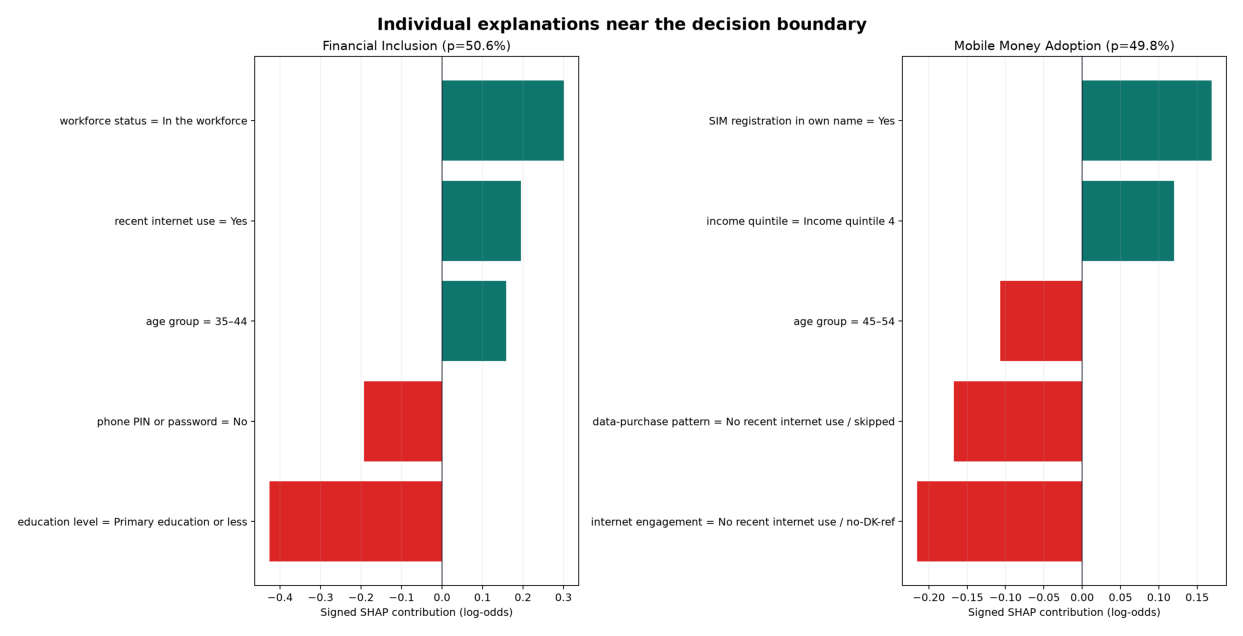

In [3]:
individual = pd.read_csv(report_dir / 'individual_explanations.csv')
boundary = individual[individual['example_type'] == 'boundary']
display(boundary[['model_label', 'prediction_statement', 'probability', 'factor_rank', 'feature_label', 'profile_value', 'direction', 'shap_log_odds']].round(4))
image = mpimg.imread(report_dir / 'figures' / '02_individual_explanations.png')
plt.figure(figsize=(16, 8))
plt.imshow(image)
plt.axis('off')
plt.show()

## Faithfulness and limitations

The raw model score, reconstructed probability, source-feature aggregation, and saved-explainer reload are all checked before artifacts are accepted.

In [4]:
validation = pd.read_csv(report_dir / 'additivity_validation.csv')
display(validation)
print('Maximum probability reconstruction error:', summary['validation']['max_probability_error'])
print('Pipeline hashes unchanged:', summary['validation']['model_pipeline_hashes_unchanged'])
print('\nLimitations:')
for limitation in summary['limitations']:
    print('•', limitation)

,model,explainer_type,holdout_rows,encoded_features,source_features,max_raw_score_error,max_probability_error,max_source_aggregation_error,explainer_reload_match,pipeline_sha256,explainer_sha256
0,model1,TreeExplainer,211,58,15,2.664535e-15,3.330669e-16,4.440892e-16,True,467e5519c022a0c716e38bae3f7b44752b4a50da655372...,b0907befa8bf8e62a8fe193bdbbcde73e1b306197f9c5e...
1,model2,LinearExplainer,210,72,16,4.440892e-16,2.220446e-16,4.440892e-16,True,3df51a31fc420043b8e386c73d2a46771cafe64a619d69...,e28a9cdb90d61f5c777f3f532b07518ef4720a7d8f0ebf...


Maximum probability reconstruction error: 3.3306690738754696e-16
Pipeline hashes unchanged: True

Limitations:
• SHAP explains model behaviour rather than causation
• attributions are relative to each explainer baseline
• conceptually overlapping features can share attribution
• global importance is evaluated on finite protected holdouts
• the 0.50 classification threshold remains provisional
